<a href="https://colab.research.google.com/github/prometricas/Peajes_Laura_Toro/blob/main/Peajes_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



# **Pronóstico econométrico de Recaudo para flujo vehicular en peajes**
* *Autora*: Laura Maria Toro Montoya
* *Email*: _lauratoromont28@gmail.com_




---
# **1. Limpieza: revisión de continuidad e imputación de faltantes**
---
### Propósito de esta fase
En esta etapa preparo la serie diaria para que quede **continua, ordenada y coherente** antes de construir variables exógenas o ajustar modelos de pronóstico.

El objetivo principal es:

- verificar que la frecuencia sea **diaria**,
- identificar fechas faltantes,
- completar esos huecos con una regla **simple, explicable y consistente con la estacionalidad semanal**,
- dejar una base limpia para las fases siguientes.

---

### Revisión de continuidad de la serie
Primero comparo la base original contra un calendario diario completo entre la fecha mínima y la fecha máxima observada.  
Con esa validación aparecen **tres fechas faltantes**:

- **2022-07-28**
- **2022-08-06**
- **2022-11-17**

Estas ausencias son **aisladas**, por lo que no se requiere una estrategia compleja de reconstrucción.

> **Criterio adoptado:** en lugar de usar una interpolación lineal simple entre días consecutivos, completo cada hueco con una **imputación estacional de 7 días**, porque la serie presenta un patrón semanal muy marcado.

---

### Regla de imputación aplicada
Para cada fecha faltante \( t \), estimo el valor a partir del mismo día de la semana anterior y del mismo día de la semana siguiente.

_Ecuación para el recaudo:_

$$
\hat{R}_t = \frac{R_{t-7} + R_{t+7}}{2}
$$

_Ecuación para los movimientos_:

$$
\hat{M}_t = \frac{M_{t-7} + M_{t+7}}{2}
$$


---

### Justificación metodológica
Esta decisión se toma porque:

**1.** La serie tiene una **estacionalidad semanal fuerte**.  
**2.** Las fechas faltantes no forman bloques largos, sino huecos puntuales.  
**3.** La imputación con \( t-7 \) y \( t+7 \) conserva mejor el comportamiento típico del mismo día de la semana.  
**4.** El procedimiento es **fácil de explicar en una exposición** y deja una trazabilidad clara.

> En términos prácticos, esta regla evita que un jueves o un sábado faltante quede arrastrado por valores atípicos del día inmediatamente anterior o posterior.

---

### Resultado esperado de esta fase
Al finalizar esta etapa, la base debe quedar con:

- una secuencia diaria completa,
- **cero valores faltantes** en las variables principales,
- una marca de control para identificar qué registros fueron imputados,
- gráficos que permitan mostrar el **antes y el después** de la imputación.

---

### Variables tratadas en esta fase
En esta limpieza inicial se corrigen las dos variables base del problema:

| Variable | Descripción |
|---|---|
| **recaudo** | Valor diario recaudado en peajes |
| **movimientos** | Número diario de movimientos registrados |

---

Saving data_peajes.xlsx to data_peajes (5).xlsx
Saving SICOM_2025.xlsx to SICOM_2025 (5).xlsx
Dimensión original: (1823, 4)

Columnas detectadas: ['fecha', 'dia_semana', 'recaudo', 'movimientos']

Primeras filas:


,fecha,dia_semana,recaudo,movimientos
0,2021-01-01,Viernes,9695800,669
1,2021-01-02,Sabado,31887100,1814
2,2021-01-03,Domingo,94734100,7500
3,2021-01-04,Lunes,134606100,8391
4,2021-01-05,Martes,144778800,8703



Fechas faltantes detectadas:
['2022-07-28', '2022-08-06', '2022-11-17']

Valores imputados:


,fecha,dia_semana,recaudo,movimientos
573,2022-07-28,Jueves,176886800,10292
582,2022-08-06,Sabado,181892450,12215
685,2022-11-17,Jueves,222065350,13406


Fechas duplicadas: 0
Nulos en fecha: 0
Nulos en recaudo: 0
Nulos en movimientos: 0

Saltos entre fechas después de limpiar:


,conteo
fecha,
1 days,1825


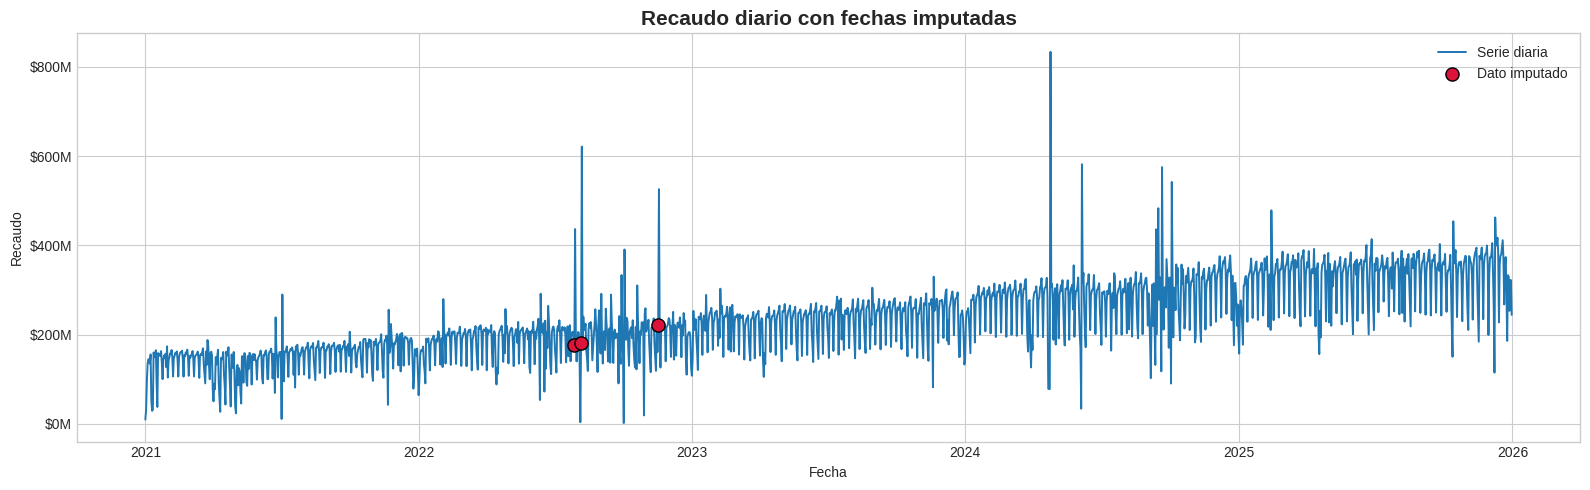

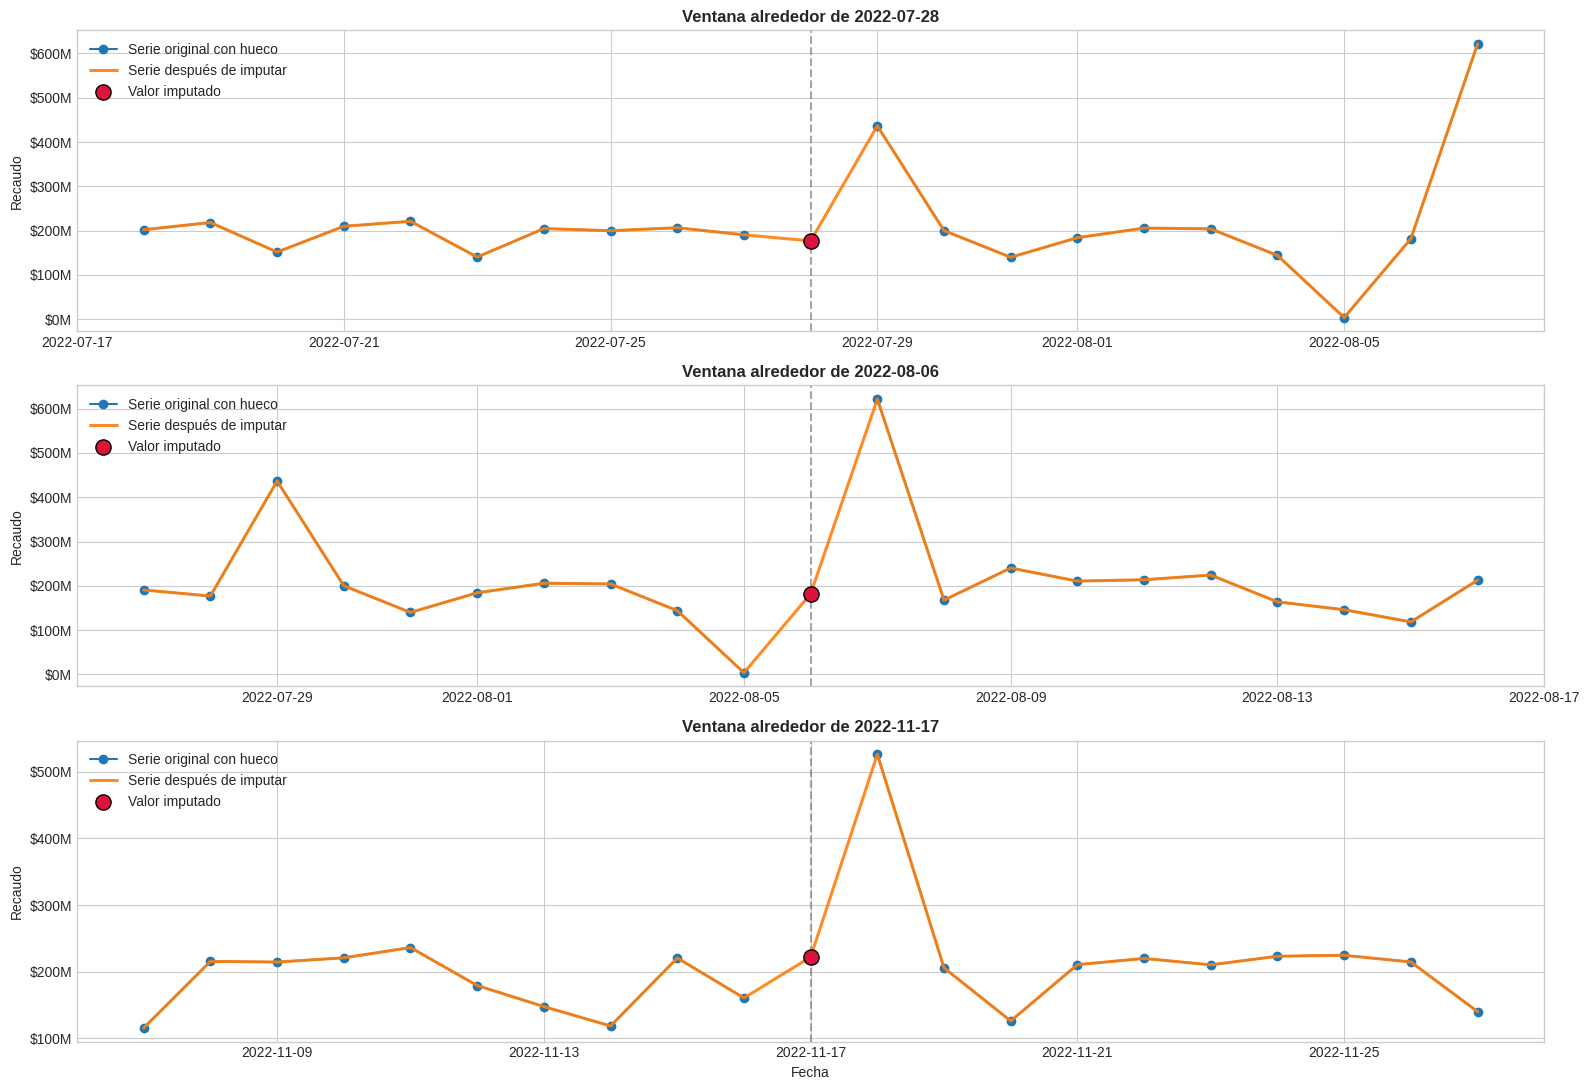

In [46]:
# Librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
plt.style.use("seaborn-v0_8-whitegrid")

# ------------------------------------------------------------
# 1. Carga de la base
# ------------------------------------------------------------

# Si hace falta subirlo manualmente, se puede usar esto:
from google.colab import files
files.upload()
ruta_excel = "/content/data_peajes.xlsx"

# Cargo la base original
df = pd.read_excel(ruta_excel)

# Estandarizo nombres para evitar errores por tildes o espacios
df.columns = (
    df.columns
      .str.strip()
      .str.lower()
      .str.replace(" ", "_")
      .str.normalize("NFKD")
      .str.encode("ascii", errors="ignore")
      .str.decode("utf-8")
)

# Convierto fecha y ordeno la serie
df["fecha"] = pd.to_datetime(df["fecha"])
df = df.sort_values("fecha").reset_index(drop=True)

print("Dimensión original:", df.shape)
print("\nColumnas detectadas:", df.columns.tolist())
print("\nPrimeras filas:")
display(df.head())

# ------------------------------------------------------------
# 2. Revisión de continuidad diaria
# ------------------------------------------------------------

# Armo un calendario diario completo desde la primera hasta la última fecha
calendario = pd.DataFrame({
    "fecha": pd.date_range(df["fecha"].min(), df["fecha"].max(), freq="D")
})

# Uno la base contra ese calendario para detectar huecos
base = calendario.merge(df, on="fecha", how="left")

# Marco las filas que quedaron vacías por ausencia en la fuente
base["es_imputado"] = base["recaudo"].isna()

faltantes = base.loc[base["es_imputado"], "fecha"].copy()

print("\nFechas faltantes detectadas:")
print(faltantes.dt.strftime("%Y-%m-%d").tolist())

# ------------------------------------------------------------
# 3. Completo el día de la semana desde la fecha
# ------------------------------------------------------------

dias_es = {
    "Monday": "Lunes",
    "Tuesday": "Martes",
    "Wednesday": "Miercoles",
    "Thursday": "Jueves",
    "Friday": "Viernes",
    "Saturday": "Sabado",
    "Sunday": "Domingo"
}

base["dia_semana"] = base["fecha"].dt.day_name().map(dias_es)

# ------------------------------------------------------------
# 4. Imputación simple y fácil de explicar
# ------------------------------------------------------------

# Tomo la fecha como índice para usar desplazamientos de 7 días
base = base.set_index("fecha")

# Para cada fecha faltante:
# imputo con el promedio del mismo día de la semana
# de la semana anterior y la siguiente
for fecha in faltantes:
    for col in ["recaudo", "movimientos"]:
        valor_semana_anterior = base.loc[fecha - pd.Timedelta(days=7), col]
        valor_semana_siguiente = base.loc[fecha + pd.Timedelta(days=7), col]
        base.loc[fecha, col] = (valor_semana_anterior + valor_semana_siguiente) / 2

base = base.reset_index()

# Redondeo porque ambas variables deben quedar enteras
base["recaudo"] = base["recaudo"].round(0).astype("int64")
base["movimientos"] = base["movimientos"].round(0).astype("int64")

print("\nValores imputados:")
display(base.loc[base["es_imputado"], ["fecha", "dia_semana", "recaudo", "movimientos"]])

# ------------------------------------------------------------
# 5. Validaciones rápidas
# ------------------------------------------------------------

print("Fechas duplicadas:", base["fecha"].duplicated().sum())
print("Nulos en fecha:", base["fecha"].isna().sum())
print("Nulos en recaudo:", base["recaudo"].isna().sum())
print("Nulos en movimientos:", base["movimientos"].isna().sum())

print("\nSaltos entre fechas después de limpiar:")
display(base["fecha"].diff().dropna().value_counts().to_frame("conteo"))

# ------------------------------------------------------------
# 6. Gráfico general con las fechas imputadas
# ------------------------------------------------------------

def formato_millones(x, pos):
    return f"${x/1e6:,.0f}M".replace(",", ".")

fig, ax = plt.subplots(figsize=(16, 5))

ax.plot(base["fecha"], base["recaudo"], linewidth=1.4, label="Serie diaria")
ax.scatter(
    base.loc[base["es_imputado"], "fecha"],
    base.loc[base["es_imputado"], "recaudo"],
    s=90,
    color="crimson",
    edgecolor="black",
    zorder=5,
    label="Dato imputado"
)

ax.set_title("Recaudo diario con fechas imputadas", fontsize=15, weight="bold")
ax.set_xlabel("Fecha")
ax.set_ylabel("Recaudo")
ax.yaxis.set_major_formatter(FuncFormatter(formato_millones))
ax.legend()
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 7. Zoom de cada imputación para exposición
# ------------------------------------------------------------

fig, axes = plt.subplots(3, 1, figsize=(16, 11), sharey=False)

for ax, fecha in zip(axes, faltantes):
    ventana = base[
        (base["fecha"] >= fecha - pd.Timedelta(days=10)) &
        (base["fecha"] <= fecha + pd.Timedelta(days=10))
    ].copy()

    # Recreo la serie con el hueco original para mostrar el antes
    ventana_hueco = ventana.copy()
    ventana_hueco.loc[ventana_hueco["fecha"] == fecha, "recaudo"] = np.nan

    ax.plot(
        ventana_hueco["fecha"],
        ventana_hueco["recaudo"],
        marker="o",
        linewidth=1.5,
        label="Serie original con hueco"
    )

    ax.plot(
        ventana["fecha"],
        ventana["recaudo"],
        linewidth=2.2,
        alpha=0.90,
        label="Serie después de imputar"
    )

    punto = ventana.loc[ventana["fecha"] == fecha]

    ax.scatter(
        punto["fecha"],
        punto["recaudo"],
        s=120,
        color="crimson",
        edgecolor="black",
        zorder=6,
        label="Valor imputado"
    )

    ax.axvline(fecha, color="gray", linestyle="--", alpha=0.7)
    ax.set_title(f"Ventana alrededor de {fecha.strftime('%Y-%m-%d')}", fontsize=12, weight="bold")
    ax.set_ylabel("Recaudo")
    ax.yaxis.set_major_formatter(FuncFormatter(formato_millones))
    ax.legend(loc="upper left")

axes[-1].set_xlabel("Fecha")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 8. Guardo la base limpia de Fase 1
# ------------------------------------------------------------
base = base.sort_values("fecha").reset_index(drop=True)


# **2. Construcción de 'variables explicativas'**
En esa siguiente etapa se incorporarán potenciales variables explicativas y covariables relevantes para mejorar el pronóstico.

## **2.1. Precios de combustible**

Extracción de precios de combustible desde la página web:

https://www.upme.gov.co/simec/hidrocarburos/combustibles-liquidos/informacion-de-precios-mensuales-en-estaciones-de-servicio/

In [47]:
import re
import unicodedata
from openpyxl import load_workbook

# ------------------------------------------------------------
# 1. Abro el archivo ya cargado en Colab
# ------------------------------------------------------------

ruta_excel = "/content/SICOM_2025.xlsx"
wb = load_workbook(ruta_excel, data_only=True)

# ------------------------------------------------------------
# 2. Defino funciones de apoyo para buscar de forma flexible
# ------------------------------------------------------------

def normalizar_texto(valor):
    """
    Convierto cualquier texto a una forma comparable:
    - sin tildes
    - en mayúscula
    - sin espacios sobrantes
    """
    if valor is None:
        return ""
    texto = str(valor).strip()
    texto = unicodedata.normalize("NFKD", texto).encode("ascii", "ignore").decode("utf-8")
    texto = re.sub(r"\s+", " ", texto.upper())
    return texto

def extraer_mes_desde_hoja(nombre_hoja):
    """
    Identifico el mes a partir del nombre de la hoja.
    """
    nombre = normalizar_texto(nombre_hoja)

    meses = {
        "ENERO": 1,
        "FEBRERO": 2,
        "MARZO": 3,
        "ABRIL": 4,
        "MAYO": 5,
        "JUNIO": 6,
        "JULIO": 7,
        "AGOSTO": 8,
        "SEPTIEMBRE": 9,
        "SETIEMBRE": 9,
        "OCTUBRE": 10,
        "NOVIEMBRE": 11,
        "DICIEMBRE": 12,
    }

    for nombre_mes, numero_mes in meses.items():
        if nombre_mes in nombre:
            return numero_mes

    return None

def buscar_fila_seccion(ws, etiqueta):
    """
    Localizo la fila donde empieza cada bloque:
    ACPM, GMC o GME.
    """
    etiqueta = normalizar_texto(etiqueta)

    for fila in ws.iter_rows():
        for celda in fila:
            texto = normalizar_texto(celda.value)

            if etiqueta == "GME":
                if texto in {"GME", "GME*"}:
                    return celda.row
            else:
                if texto == etiqueta:
                    return celda.row

    return None

def buscar_columna_promedio(ws, fila_header):
    """
    Encuentro la columna cuyo encabezado sea 'Promedio'.
    """
    for col in range(1, ws.max_column + 1):
        texto = normalizar_texto(ws.cell(fila_header, col).value)
        if texto == "PROMEDIO":
            return col
    return None

def extraer_valor_medin(ws, fila_seccion):
    """
    Desde la fila de encabezado de una sección, busco la fila de Medellín
    y extraigo el valor de la columna Promedio.
    """
    if fila_seccion is None:
        return None

    col_promedio = buscar_columna_promedio(ws, fila_seccion)
    if col_promedio is None:
        return None

    # Recorro hacia abajo hasta encontrar una fila vacía larga
    # o hasta toparme con otra sección importante
    for fila in range(fila_seccion + 1, min(ws.max_row, fila_seccion + 40) + 1):
        etiqueta_fila = normalizar_texto(ws.cell(fila, 2).value)

        if etiqueta_fila in {"", "PRECIOS SICOM", "ACPM", "GMC", "GME", "GME*"}:
            continue

        if etiqueta_fila == "MEDELLIN":
            valor = ws.cell(fila, col_promedio).value
            if isinstance(valor, (int, float)):
                return float(valor)

    return None

# ------------------------------------------------------------
# 3. Recorro hojas y extraigo Medellín para cada combustible
# ------------------------------------------------------------

registros = []

for nombre_hoja in wb.sheetnames:
    ws = wb[nombre_hoja]

    mes = extraer_mes_desde_hoja(nombre_hoja)
    if mes is None:
        continue

    fila_acpm = buscar_fila_seccion(ws, "ACPM")
    fila_gmc  = buscar_fila_seccion(ws, "GMC")
    fila_gme  = buscar_fila_seccion(ws, "GME")

    acpm = extraer_valor_medin(ws, fila_acpm)
    gmc  = extraer_valor_medin(ws, fila_gmc)
    gme  = extraer_valor_medin(ws, fila_gme)

    registros.append({
        "fecha": pd.Timestamp(year=2025, month=mes, day=1),
        "ACPM": acpm,
        "GMC": gmc,
        "GME": gme
    })

# ------------------------------------------------------------
# 4. Construyo el dataframe final
# ------------------------------------------------------------

df_combustibles = (
    pd.DataFrame(registros)
      .sort_values("fecha")
      .reset_index(drop=True)
)

# Dejo la fecha en formato mes-2025
df_combustibles["fecha"] = df_combustibles["fecha"].dt.strftime("%Y-%m")

print("DataFrame final:")
display(df_combustibles)

# ------------------------------------------------------------
# 5. Validación rápida
# ------------------------------------------------------------

print("\nNulos por columna:")
print(df_combustibles.isna().sum())

DataFrame final:


,fecha,ACPM,GMC,GME
0,2025-01,10883.408542,16869.106302,21036.597701
1,2025-02,10996.409910,16976.912945,21039.581395
2,2025-03,11135.780193,16020.735897,20481.792453
3,2025-04,11097.166667,16008.318841,20507.917910
4,2025-05,11117.779412,16044.805970,21222.968750
5,2025-06,11117.108974,16068.211268,21189.344262
6,2025-07,11159.054545,16041.113208,21159.240000
7,2025-08,11182.225490,16064.573770,21086.684524
8,2025-09,11169.010101,16051.450549,21020.689873
9,2025-10,11229.740000,16109.795699,20902.890244



Nulos por columna:
fecha    0
ACPM     0
GMC      0
GME      0
dtype: int64


In [48]:
# CONVIERTO EL DATAFRAME MENSUAL DE COMBUSTIBLES A DIARIO
# Y LO UNO CON LA BASE DIARIA DE LA FASE 1

# ------------------------------------------------------------
# 1. Reviso tipos y estandarizo la fecha del dataframe mensual
# ------------------------------------------------------------

# Trabajo sobre una copia para no alterar el dataframe original
combustibles_mensual = df_combustibles.copy()

# Aseguro que la fecha quede en formato datetime
# Este bloque soporta fechas tipo "2025-01" o datetime
combustibles_mensual["fecha"] = pd.to_datetime(combustibles_mensual["fecha"], format="%Y-%m", errors="coerce")

# Quito filas con fecha inválida, si aparecieran
combustibles_mensual = combustibles_mensual.dropna(subset=["fecha"]).copy()

# Ordeno por fecha
combustibles_mensual = combustibles_mensual.sort_values("fecha").reset_index(drop=True)

# ------------------------------------------------------------
# 2. Expando cada mes a frecuencia diaria
# ------------------------------------------------------------

# Creo el rango diario cubierto por los combustibles disponibles
fecha_inicio = combustibles_mensual["fecha"].min()
fecha_fin = combustibles_mensual["fecha"].max() + pd.offsets.MonthEnd(0)

combustibles_diario = pd.DataFrame({
    "fecha": pd.date_range(start=fecha_inicio, end=fecha_fin, freq="D")
})

# Uno por la fecha del primer día de cada mes
combustibles_diario = combustibles_diario.merge(
    combustibles_mensual,
    on="fecha",
    how="left"
)

# Completo hacia adelante para que cada precio mensual
# se replique en todos los días del mismo mes
combustibles_diario[["ACPM", "GMC", "GME"]] = (
    combustibles_diario[["ACPM", "GMC", "GME"]].ffill()
)

#print("DataFrame diario de combustibles:")
#display(combustibles_diario.head(35))

# ------------------------------------------------------------
# 3. Preparo la base diaria para el merge
# ------------------------------------------------------------

base["fecha"] = pd.to_datetime(base["fecha"])
base = base.sort_values("fecha").reset_index(drop=True)

# ------------------------------------------------------------
# 4. Hago el merge con la base diaria
# ------------------------------------------------------------

base = base.merge(
    combustibles_diario,
    on="fecha",
    how="left"
)

# ------------------------------------------------------------
# 5. Borro filas donde hayan quedado vacíos los combustibles
# ------------------------------------------------------------

base = base.dropna(subset=["ACPM", "GMC", "GME"]).reset_index(drop=True)

# ------------------------------------------------------------
# 6. Validación rápida
# ------------------------------------------------------------

print("Dimensión final de base:", base.shape)
print("\nRango de fechas final:")
print(base["fecha"].min(), "->", base["fecha"].max())

print("\nNulos por columna de combustibles:")
print(base[["ACPM", "GMC", "GME"]].isna().sum())

print("\nVista previa de base con combustibles:")
display(base.head())

Dimensión final de base: (365, 8)

Rango de fechas final:
2025-01-01 00:00:00 -> 2025-12-31 00:00:00

Nulos por columna de combustibles:
ACPM    0
GMC     0
GME     0
dtype: int64

Vista previa de base con combustibles:


,fecha,dia_semana,recaudo,movimientos,es_imputado,ACPM,GMC,GME
0,2025-01-01,Miercoles,157445700,9354,False,10883.408542,16869.106302,21036.597701
1,2025-01-02,Jueves,261963000,12695,False,10883.408542,16869.106302,21036.597701
2,2025-01-03,Viernes,276621800,13199,False,10883.408542,16869.106302,21036.597701
3,2025-01-04,Sabado,259619200,13586,False,10883.408542,16869.106302,21036.597701
4,2025-01-05,Domingo,226524800,12264,False,10883.408542,16869.106302,21036.597701


### **2.1.1. Gráficas: combustible**

In [49]:
import plotly.graph_objects as go

# ------------------------------------------------------------
# 1. Preparo el dataframe para graficar
# ------------------------------------------------------------

# Trabajo sobre una copia para evitar cambios accidentales
comb_plot = combustibles_diario.copy()

# Aseguro formato de fecha
comb_plot["fecha"] = pd.to_datetime(comb_plot["fecha"])

# Quito posibles duplicados si existieran
comb_plot = comb_plot.drop_duplicates(subset=["fecha"]).sort_values("fecha").reset_index(drop=True)

# ------------------------------------------------------------
# 2. Construyo la gráfica interactiva
# ------------------------------------------------------------

fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=comb_plot["fecha"],
        y=comb_plot["ACPM"],
        mode="lines",
        name="ACPM",
        line=dict(width=3),
        hovertemplate="<b>Fecha:</b> %{x|%Y-%m-%d}<br><b>ACPM:</b> $%{y:,.0f}<extra></extra>"
    )
)

fig.add_trace(
    go.Scatter(
        x=comb_plot["fecha"],
        y=comb_plot["GMC"],
        mode="lines",
        name="GMC",
        line=dict(width=3),
        hovertemplate="<b>Fecha:</b> %{x|%Y-%m-%d}<br><b>GMC:</b> $%{y:,.0f}<extra></extra>"
    )
)

fig.add_trace(
    go.Scatter(
        x=comb_plot["fecha"],
        y=comb_plot["GME"],
        mode="lines",
        name="GME",
        line=dict(width=3),
        hovertemplate="<b>Fecha:</b> %{x|%Y-%m-%d}<br><b>GME:</b> $%{y:,.0f}<extra></extra>"
    )
)

# ------------------------------------------------------------
# 3. Ajusto el diseño para que se vea bien en exposición
# ------------------------------------------------------------

fig.update_layout(
    title=dict(
        text="Evolución diaria de precios promedio de combustibles en Medellín (2025)",
        x=0.5,
        xanchor="center"
    ),
    xaxis_title="Fecha",
    yaxis_title="Precio promedio",
    template="plotly_white",
    hovermode="x unified",
    height=600,
    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=1.02,
        xanchor="center",
        x=0.5
    ),
    margin=dict(l=50, r=50, t=90, b=50)
)

fig.update_yaxes(tickprefix="$", separatethousands=True)

# ------------------------------------------------------------
# 4. Agrego controles útiles para explorar la serie
# ------------------------------------------------------------

fig.update_xaxes(
    rangeslider_visible=True,
    rangeselector=dict(
        buttons=[
            dict(count=1, label="1m", step="month", stepmode="backward"),
            dict(count=3, label="3m", step="month", stepmode="backward"),
            dict(count=6, label="6m", step="month", stepmode="backward"),
            dict(label="Todo", step="all")
        ]
    )
)

# ------------------------------------------------------------
# 5. Muestro la gráfica
# ------------------------------------------------------------

fig.show()

## **2.2. Variables calendario**
Variables de calendario parsimoniosas: evitando colinealidad y redundancia por rezagos.



In [50]:
# ------------------------------------------------------------
# 1. Parto de la base actual en memoria
# ------------------------------------------------------------
df_modelo = base.copy()
df_modelo["fecha"] = pd.to_datetime(df_modelo["fecha"])
df_modelo = df_modelo.sort_values("fecha").reset_index(drop=True)

# Como combustibles solo está en 2025, dejo ese año
df_modelo = df_modelo[df_modelo["fecha"].dt.year == 2025].copy()

# ------------------------------------------------------------
# 2. Defino festivos nacionales de Colombia para 2025
# ------------------------------------------------------------

festivos_2025 = pd.to_datetime([
    "2025-01-01",
    "2025-01-06",
    "2025-03-24",
    "2025-04-17",
    "2025-04-18",
    "2025-05-01",
    "2025-06-02",
    "2025-06-23",
    "2025-06-30",
    "2025-07-20",
    "2025-08-07",
    "2025-08-18",
    "2025-10-13",
    "2025-11-03",
    "2025-11-17",
    "2025-12-08",
    "2025-12-25"
]).drop_duplicates().sort_values()

festivos_set = set(festivos_2025)

# ------------------------------------------------------------
# 3. Defino ventanas calendario relevantes
# ------------------------------------------------------------

semana_santa_inicio = pd.Timestamp("2025-04-13")
semana_santa_fin = pd.Timestamp("2025-04-20")

vac_mitad_inicio = pd.Timestamp("2025-06-16")
vac_mitad_fin = pd.Timestamp("2025-07-06")

receso_oct_inicio = pd.Timestamp("2025-10-06")
receso_oct_fin = pd.Timestamp("2025-10-12")

temporada_fin_ano_inicio = pd.Timestamp("2025-12-15")
temporada_fin_ano_fin = pd.Timestamp("2025-12-31")

# ------------------------------------------------------------
# 4. Construyo solo las variables más importantes
# ------------------------------------------------------------

df_modelo["festivo_colombia"] = df_modelo["fecha"].isin(festivos_set).astype(int)

df_modelo["puente_festivo"] = (
    (df_modelo["festivo_colombia"] == 1) &
    (df_modelo["fecha"].dt.dayofweek == 0)
).astype(int)

df_modelo["semana_santa"] = (
    (df_modelo["fecha"] >= semana_santa_inicio) &
    (df_modelo["fecha"] <= semana_santa_fin)
).astype(int)

df_modelo["vacaciones_mitad_ano"] = (
    (df_modelo["fecha"] >= vac_mitad_inicio) &
    (df_modelo["fecha"] <= vac_mitad_fin)
).astype(int)

df_modelo["receso_octubre"] = (
    (df_modelo["fecha"] >= receso_oct_inicio) &
    (df_modelo["fecha"] <= receso_oct_fin)
).astype(int)

df_modelo["temporada_fin_de_ano"] = (
    (df_modelo["fecha"] >= temporada_fin_ano_inicio) &
    (df_modelo["fecha"] <= temporada_fin_ano_fin)
).astype(int)

# ------------------------------------------------------------
# 5. Reordeno columnas
# ------------------------------------------------------------

columnas_calendario = [
    "festivo_colombia",
    "puente_festivo",
    "semana_santa",
    "vacaciones_mitad_ano",
    "receso_octubre",
    "temporada_fin_de_ano"
]

otras_columnas = [c for c in df_modelo.columns if c not in columnas_calendario]
df_modelo = df_modelo[otras_columnas + columnas_calendario]

# ------------------------------------------------------------
# 6. Validación rápida
# ------------------------------------------------------------

print("Dimensión final del dataframe:", df_modelo.shape)
print("\nColumnas calendario incluidas:")
print(columnas_calendario)

print("\nSuma de activaciones por variable:")
display(df_modelo[columnas_calendario].sum().to_frame("conteo"))

print("\nVista previa:")
display(df_modelo.head())

Dimensión final del dataframe: (365, 14)

Columnas calendario incluidas:
['festivo_colombia', 'puente_festivo', 'semana_santa', 'vacaciones_mitad_ano', 'receso_octubre', 'temporada_fin_de_ano']

Suma de activaciones por variable:


,conteo
festivo_colombia,17
puente_festivo,10
semana_santa,8
vacaciones_mitad_ano,21
receso_octubre,7
temporada_fin_de_ano,17



Vista previa:


,fecha,dia_semana,recaudo,movimientos,es_imputado,ACPM,GMC,GME,festivo_colombia,puente_festivo,semana_santa,vacaciones_mitad_ano,receso_octubre,temporada_fin_de_ano
0,2025-01-01,Miercoles,157445700,9354,False,10883.408542,16869.106302,21036.597701,1,0,0,0,0,0
1,2025-01-02,Jueves,261963000,12695,False,10883.408542,16869.106302,21036.597701,0,0,0,0,0,0
2,2025-01-03,Viernes,276621800,13199,False,10883.408542,16869.106302,21036.597701,0,0,0,0,0,0
3,2025-01-04,Sabado,259619200,13586,False,10883.408542,16869.106302,21036.597701,0,0,0,0,0,0
4,2025-01-05,Domingo,226524800,12264,False,10883.408542,16869.106302,21036.597701,0,0,0,0,0,0


## **2.3. Variables metereológicas**
Descargo variables climáticas diarias desde Open-Meteo y las uno al dataframe df_modelo en memoria


In [51]:
import time
import requests

# ------------------------------------------------------------
# 1. Parto del dataframe que ya viene armado en memoria
# ------------------------------------------------------------

df_modelo["fecha"] = pd.to_datetime(df_modelo["fecha"])
df_modelo = df_modelo.sort_values("fecha").reset_index(drop=True)

# ------------------------------------------------------------
# 2. Defino la consulta al API histórico de Open-Meteo
# ------------------------------------------------------------

# Medellín, Colombia
latitud = 6.2442
longitud = -75.5812

fecha_inicio = "2025-01-01"
fecha_fin = "2025-12-31"

url = "https://archive-api.open-meteo.com/v1/archive"

params = {
    "latitude": latitud,
    "longitude": longitud,
    "start_date": fecha_inicio,
    "end_date": fecha_fin,
    "daily": [
        "precipitation_sum",      # lluvia total del día en mm
        "precipitation_hours",    # número de horas con precipitación
        "temperature_2m_mean",    # temperatura media diaria
        "temperature_2m_max",     # temperatura máxima diaria
        "temperature_2m_min"      # temperatura mínima diaria
    ],
    "timezone": "America/Bogota"
}

# ------------------------------------------------------------
# 3. Hago la petición con reintentos para que sea más robusta
# ------------------------------------------------------------

respuesta = None
ultimo_error = None

for intento in range(5):
    try:
        respuesta = requests.get(url, params=params, timeout=60)
        respuesta.raise_for_status()
        datos = respuesta.json()

        if "daily" not in datos:
            raise ValueError("La respuesta no trae el bloque 'daily'.")

        break

    except Exception as e:
        ultimo_error = e
        time.sleep(2)

if respuesta is None:
    raise RuntimeError(f"No fue posible consultar el API de clima. Error: {ultimo_error}")

# ------------------------------------------------------------
# 4. Convierto la respuesta en dataframe
# ------------------------------------------------------------

clima = pd.DataFrame({
    "fecha": pd.to_datetime(datos["daily"]["time"]),
    "lluvia_mm": datos["daily"]["precipitation_sum"],
    "horas_lluvia": datos["daily"]["precipitation_hours"],
    "temp_media_c": datos["daily"]["temperature_2m_mean"],
    "temp_max_c": datos["daily"]["temperature_2m_max"],
    "temp_min_c": datos["daily"]["temperature_2m_min"]
})

# ------------------------------------------------------------
# 5. Validación rápida del clima descargado
# ------------------------------------------------------------

print("Dimensión del dataframe climático:", clima.shape)
print("\nPrimeras filas del clima:")
display(clima.head())

print("\nNulos por columna:")
print(clima.isna().sum())

if clima.empty:
    raise ValueError("El dataframe climático quedó vacío.")

# ------------------------------------------------------------
# 6. Uno clima con el dataframe del proyecto
# ------------------------------------------------------------

df_modelo = df_modelo.merge(
    clima,
    on="fecha",
    how="left"
)

# Si después del merge quedaron días sin clima, los elimino
columnas_clima = ["lluvia_mm", "horas_lluvia", "temp_media_c", "temp_max_c", "temp_min_c"]

df_modelo = df_modelo.dropna(subset=columnas_clima).reset_index(drop=True)

# ------------------------------------------------------------
# 7. Validación final
# ------------------------------------------------------------

print("Dimensión final de df_modelo:", df_modelo.shape)
print("\nRango de fechas final:")
print(df_modelo["fecha"].min(), "->", df_modelo["fecha"].max())

print("\nNulos en variables de clima:")
print(df_modelo[columnas_clima].isna().sum())

print("\nVista previa del dataframe completo:")
display(df_modelo.head())

Dimensión del dataframe climático: (365, 6)

Primeras filas del clima:


,fecha,lluvia_mm,horas_lluvia,temp_media_c,temp_max_c,temp_min_c
0,2025-01-01,13.5,10.0,19.3,26.1,15.5
1,2025-01-02,10.0,6.0,19.6,26.3,16.0
2,2025-01-03,8.8,12.0,19.0,23.4,15.6
3,2025-01-04,19.4,17.0,19.5,25.7,15.5
4,2025-01-05,20.2,13.0,19.6,25.3,16.4



Nulos por columna:
fecha           0
lluvia_mm       0
horas_lluvia    0
temp_media_c    0
temp_max_c      0
temp_min_c      0
dtype: int64
Dimensión final de df_modelo: (365, 19)

Rango de fechas final:
2025-01-01 00:00:00 -> 2025-12-31 00:00:00

Nulos en variables de clima:
lluvia_mm       0
horas_lluvia    0
temp_media_c    0
temp_max_c      0
temp_min_c      0
dtype: int64

Vista previa del dataframe completo:


,fecha,dia_semana,recaudo,movimientos,es_imputado,ACPM,GMC,GME,festivo_colombia,puente_festivo,semana_santa,vacaciones_mitad_ano,receso_octubre,temporada_fin_de_ano,lluvia_mm,horas_lluvia,temp_media_c,temp_max_c,temp_min_c
0,2025-01-01,Miercoles,157445700,9354,False,10883.408542,16869.106302,21036.597701,1,0,0,0,0,0,13.5,10.0,19.3,26.1,15.5
1,2025-01-02,Jueves,261963000,12695,False,10883.408542,16869.106302,21036.597701,0,0,0,0,0,0,10.0,6.0,19.6,26.3,16.0
2,2025-01-03,Viernes,276621800,13199,False,10883.408542,16869.106302,21036.597701,0,0,0,0,0,0,8.8,12.0,19.0,23.4,15.6
3,2025-01-04,Sabado,259619200,13586,False,10883.408542,16869.106302,21036.597701,0,0,0,0,0,0,19.4,17.0,19.5,25.7,15.5
4,2025-01-05,Domingo,226524800,12264,False,10883.408542,16869.106302,21036.597701,0,0,0,0,0,0,20.2,13.0,19.6,25.3,16.4


### **2.3.1. Gráficas: metereológicas**

In [52]:
import plotly.graph_objects as go

# ------------------------------------------------------------
# 1. Preparo el dataframe para graficar
# ------------------------------------------------------------

meteo_plot = df_modelo.copy()

meteo_plot["fecha"] = pd.to_datetime(meteo_plot["fecha"])
meteo_plot = meteo_plot.sort_values("fecha").reset_index(drop=True)

# ------------------------------------------------------------
# 2. Gráfica interactiva de lluvia
# ------------------------------------------------------------

fig_lluvia = go.Figure()

fig_lluvia.add_trace(
    go.Bar(
        x=meteo_plot["fecha"],
        y=meteo_plot["lluvia_mm"],
        name="Lluvia diaria (mm)",
        hovertemplate="<b>Fecha:</b> %{x|%Y-%m-%d}<br><b>Lluvia:</b> %{y:.2f} mm<extra></extra>"
    )
)

fig_lluvia.add_trace(
    go.Scatter(
        x=meteo_plot["fecha"],
        y=meteo_plot["horas_lluvia"],
        mode="lines",
        name="Horas de lluvia",
        yaxis="y2",
        line=dict(width=3),
        hovertemplate="<b>Fecha:</b> %{x|%Y-%m-%d}<br><b>Horas de lluvia:</b> %{y:.2f}<extra></extra>"
    )
)

fig_lluvia.update_layout(
    title=dict(
        text="Lluvia diaria y duración de precipitación en 2025",
        x=0.5,
        xanchor="center"
    ),
    template="plotly_white",
    height=600,
    hovermode="x unified",
    xaxis=dict(
        title="Fecha",
        rangeslider=dict(visible=True),
        rangeselector=dict(
            buttons=[
                dict(count=1, label="1m", step="month", stepmode="backward"),
                dict(count=3, label="3m", step="month", stepmode="backward"),
                dict(count=6, label="6m", step="month", stepmode="backward"),
                dict(label="Todo", step="all")
            ]
        )
    ),
    yaxis=dict(
        title="Lluvia diaria (mm)"
    ),
    yaxis2=dict(
        title="Horas de lluvia",
        overlaying="y",
        side="right"
    ),
    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=1.02,
        xanchor="center",
        x=0.5
    ),
    margin=dict(l=60, r=60, t=90, b=50)
)

fig_lluvia.show()

# ------------------------------------------------------------
# 3. Gráfica interactiva de temperaturas
# ------------------------------------------------------------

fig_temp = go.Figure()

fig_temp.add_trace(
    go.Scatter(
        x=meteo_plot["fecha"],
        y=meteo_plot["temp_max_c"],
        mode="lines",
        name="Temperatura máxima",
        line=dict(width=2.5),
        hovertemplate="<b>Fecha:</b> %{x|%Y-%m-%d}<br><b>Temp. máxima:</b> %{y:.2f} °C<extra></extra>"
    )
)

fig_temp.add_trace(
    go.Scatter(
        x=meteo_plot["fecha"],
        y=meteo_plot["temp_media_c"],
        mode="lines",
        name="Temperatura media",
        line=dict(width=3),
        hovertemplate="<b>Fecha:</b> %{x|%Y-%m-%d}<br><b>Temp. media:</b> %{y:.2f} °C<extra></extra>"
    )
)

fig_temp.add_trace(
    go.Scatter(
        x=meteo_plot["fecha"],
        y=meteo_plot["temp_min_c"],
        mode="lines",
        name="Temperatura mínima",
        line=dict(width=2.5),
        hovertemplate="<b>Fecha:</b> %{x|%Y-%m-%d}<br><b>Temp. mínima:</b> %{y:.2f} °C<extra></extra>"
    )
)

fig_temp.update_layout(
    title=dict(
        text="Comportamiento diario de la temperatura en 2025",
        x=0.5,
        xanchor="center"
    ),
    template="plotly_white",
    height=600,
    hovermode="x unified",
    xaxis=dict(
        title="Fecha",
        rangeslider=dict(visible=True),
        rangeselector=dict(
            buttons=[
                dict(count=1, label="1m", step="month", stepmode="backward"),
                dict(count=3, label="3m", step="month", stepmode="backward"),
                dict(count=6, label="6m", step="month", stepmode="backward"),
                dict(label="Todo", step="all")
            ]
        )
    ),
    yaxis=dict(
        title="Temperatura (°C)"
    ),
    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=1.02,
        xanchor="center",
        x=0.5
    ),
    margin=dict(l=60, r=60, t=90, b=50)
)

fig_temp.show()

# **3. Backtesting con validación rolling-origin**

### Propósito de esta fase
En esta etapa comparo una referencia mínima contra un modelo con variables exógenas, usando una validación rolling-origin más ligera y estable. La idea es verificar si las variables de calendario, combustibles y clima aportan capacidad predictiva fuera de muestra, sin recargar el proceso con demasiadas iteraciones ni especificaciones innecesariamente complejas.

---

### Modelos evaluados

### 1. Naive semanal
Toma como pronóstico el valor observado siete días atrás:

$$
\hat{y}_t = y_{t-7}
$$

### 2. SARIMAX con exógenas
Se trabaja sobre el logaritmo del recaudo:

$$
z_t = \log(1+y_t)
$$

y luego el pronóstico vuelve a la escala original con:

$$
\hat{y}_t = e^{\hat{z}_t} - 1
$$

---

### Criterios de simplificación
Para evitar problemas de convergencia y reducir tiempo de cómputo:

- se usa una estructura SARIMAX,
- se estandarizan las variables exógenas,
- y se controla la salida de advertencias de convergencia.

---

### Métricas de evaluación

### MAPE
$$
MAPE = \frac{100}{n}\sum_{t=1}^{n}\left|\frac{y_t-\hat{y}_t}{y_t}\right|
$$

### WAPE
$$
WAPE = 100 \cdot \frac{\sum_{t=1}^{n}|y_t-\hat{y}_t|}{\sum_{t=1}^{n}y_t}
$$

### RMSE
$$
RMSE = \sqrt{\frac{1}{n}\sum_{t=1}^{n}(y_t-\hat{y}_t)^2}
$$

In [53]:
import warnings
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tools.sm_exceptions import ConvergenceWarning

import plotly.graph_objects as go
import plotly.express as px

# ------------------------------------------------------------
# 1. Preparo la base
# ------------------------------------------------------------

warnings.filterwarnings("ignore", category=ConvergenceWarning)

bt = df_modelo.copy()
bt["fecha"] = pd.to_datetime(bt["fecha"])
bt = bt.sort_values("fecha").reset_index(drop=True)

target = "recaudo"

exog_cols = [
    "ACPM", "GMC", "GME",
    "lluvia_mm", "horas_lluvia", "temp_media_c",
    "festivo_colombia", "puente_festivo",
    "semana_santa", "vacaciones_mitad_ano",
    "receso_octubre", "temporada_fin_de_ano"
]

exog_cols = [c for c in exog_cols if c in bt.columns]

bt = bt.dropna(subset=[target] + exog_cols).copy()
bt["y_log"] = np.log1p(bt[target])

print("Filas usadas:", len(bt))
print("Exógenas usadas:", exog_cols)

# ------------------------------------------------------------
# 2. Métricas
# ------------------------------------------------------------

def mape(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    mask = y_true != 0
    return 100 * np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask]))

def wape(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return 100 * np.sum(np.abs(y_true - y_pred)) / np.sum(np.abs(y_true))

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

# ------------------------------------------------------------
# 3. Funciones de pronóstico
# ------------------------------------------------------------

def naive_semanal(train, test):
    ref = train.set_index("fecha")[target]
    ultimo = train[target].iloc[-1]
    pred = []
    for f in test["fecha"]:
        pred.append(ref.get(f - pd.Timedelta(days=7), ultimo))
    return np.array(pred)

def sarimax_simple(train, test, exog_cols):
    scaler = StandardScaler()
    X_train = scaler.fit_transform(train[exog_cols])
    X_test = scaler.transform(test[exog_cols])

    modelo = SARIMAX(
        train["y_log"],
        exog=X_train,
        order=(1, 0, 1),
        seasonal_order=(1, 0, 0, 7),
        trend="n",
        simple_differencing=True,
        enforce_stationarity=False,
        enforce_invertibility=False
    )

    ajuste = modelo.fit(disp=False, maxiter=60)

    pred_log = ajuste.forecast(steps=len(test), exog=X_test)
    pred = np.expm1(pred_log)
    return np.maximum(pred, 0)

# ------------------------------------------------------------
# 4. Backtesting rolling simple
# ------------------------------------------------------------

def backtest(data, horizon=14, train_min=180, step=14):
    metricas = []
    detalle = []

    fold = 0
    for start in range(train_min, len(data) - horizon + 1, step):
        fold += 1

        train = data.iloc[:start].copy()
        test = data.iloc[start:start + horizon].copy()

        y_true = test[target].values

        pred_naive = naive_semanal(train, test)

        try:
            pred_sarimax = sarimax_simple(train, test, exog_cols)
        except Exception:
            pred_sarimax = pred_naive.copy()

        modelos = {
            "Naive semanal": pred_naive,
            "SARIMAX": pred_sarimax
        }

        for nombre, pred in modelos.items():
            metricas.append({
                "fold": fold,
                "modelo": nombre,
                "MAPE": mape(y_true, pred),
                "WAPE": wape(y_true, pred),
                "RMSE": rmse(y_true, pred)
            })

            det = pd.DataFrame({
                "fecha": test["fecha"].values,
                "real": y_true,
                "pred": pred,
                "fold": fold,
                "modelo": nombre
            })
            det["APE"] = 100 * np.abs(det["real"] - det["pred"]) / det["real"]
            detalle.append(det)

    return pd.DataFrame(metricas), pd.concat(detalle, ignore_index=True)

metricas_bt, detalle_bt = backtest(bt, horizon=14, train_min=180, step=14)

resumen_bt = (
    metricas_bt
    .groupby("modelo", as_index=False)[["MAPE", "WAPE", "RMSE"]]
    .mean()
    .sort_values("WAPE")
    .reset_index(drop=True)
)

print("Resumen promedio del backtesting:")
display(resumen_bt)

# ------------------------------------------------------------
# 5. Gráfica 1. Serie real vs pronóstico concatenado
# ------------------------------------------------------------

mejor_modelo = resumen_bt.iloc[0]["modelo"]

real_plot = (
    detalle_bt[detalle_bt["modelo"] == mejor_modelo][["fecha", "real"]]
    .drop_duplicates()
    .sort_values("fecha")
)

pred_plot = (
    detalle_bt[detalle_bt["modelo"] == mejor_modelo][["fecha", "pred"]]
    .sort_values("fecha")
)

fig1 = go.Figure()

fig1.add_trace(go.Scatter(
    x=real_plot["fecha"],
    y=real_plot["real"],
    mode="lines",
    name="Real",
    line=dict(width=4)
))

fig1.add_trace(go.Scatter(
    x=pred_plot["fecha"],
    y=pred_plot["pred"],
    mode="lines",
    name=f"Pronóstico - {mejor_modelo}",
    line=dict(width=3, dash="dash")
))

fig1.update_layout(
    title=f"Backtesting concatenado: serie real vs {mejor_modelo}",
    template="plotly_white",
    height=550,
    hovermode="x unified",
    xaxis_title="Fecha",
    yaxis_title="Recaudo"
)

fig1.show()

# ------------------------------------------------------------
# 6. Gráfica 2. Error porcentual por fecha y modelo
# ------------------------------------------------------------

ape_plot = (
    detalle_bt
    .groupby(["fecha", "modelo"], as_index=False)["APE"]
    .mean()
)

fig2 = px.line(
    ape_plot,
    x="fecha",
    y="APE",
    color="modelo",
    title="Error porcentual absoluto medio por fecha de pronóstico"
)

fig2.update_layout(
    template="plotly_white",
    height=550,
    hovermode="x unified",
    xaxis_title="Fecha",
    yaxis_title="APE (%)"
)

fig2.show()

# ------------------------------------------------------------
# 7. Gráfica 3. Distribución del error por modelo
# ------------------------------------------------------------

fig3 = px.box(
    detalle_bt,
    x="modelo",
    y="APE",
    color="modelo",
    points="all",
    title="Distribución del error porcentual absoluto por modelo"
)

fig3.update_layout(
    template="plotly_white",
    height=550,
    xaxis_title="Modelo",
    yaxis_title="APE (%)",
    showlegend=False
)

fig3.show()

Filas usadas: 365
Exógenas usadas: ['ACPM', 'GMC', 'GME', 'lluvia_mm', 'horas_lluvia', 'temp_media_c', 'festivo_colombia', 'puente_festivo', 'semana_santa', 'vacaciones_mitad_ano', 'receso_octubre', 'temporada_fin_de_ano']
Resumen promedio del backtesting:


,modelo,MAPE,WAPE,RMSE
0,SARIMAX,7.317769,6.606998,2.984064e+07
1,Naive semanal,18.413871,18.487649,8.367583e+07


# **4. Selección del mejor modelo y pronóstico de corto plazo**

## Propósito de esta fase
En esta etapa se selecciona el modelo con mejor desempeño en el backtesting y se ajusta nuevamente sobre toda la muestra disponible, con el fin de generar un pronóstico de corto plazo sobre el recaudo.

La decisión final se basa en el error fuera de muestra, priorizando un criterio de desempeño estable y fácil de defender en términos operativos.

---

## Criterio de selección
Se toma como métrica principal el **WAPE**, porque resume el error absoluto en proporción al volumen total recaudado y resulta más interpretable para un problema de negocio.

El modelo final corresponde al que presente el menor valor promedio de WAPE en la validación rolling-origin.

---

## Ajuste final del modelo
Una vez seleccionado el mejor enfoque, el modelo se reentrena con toda la información disponible en 2025 y se proyecta un horizonte corto hacia adelante.

En este caso, el pronóstico se genera para **21 días**, porque permite mostrar una ventana suficientemente visible al final de la serie sin perder legibilidad en la gráfica.

---

## Escala del modelo
El recaudo se modela en escala logarítmica:

$$
z_t = \log(1+y_t)
$$

y luego se regresa a la escala original mediante:

$$
\hat{y}_t = e^{\hat{z}_t} - 1
$$

donde:

$$
y_t = \text{recaudo diario observado}
$$

$$
\hat{y}_t = \text{recaudo diario pronosticado}
$$

---

## Resultado esperado
Al finalizar esta etapa se obtiene:

- el modelo final seleccionado,
- un pronóstico de corto plazo sobre el recaudo,
- una visualización enfocada en la parte final de la serie,
- y una síntesis técnica del trabajo desarrollado.

Mejor modelo seleccionado: SARIMAX
Última fecha observada: 2025-12-31
Pronóstico futuro: 2026-01-01 -> 2026-01-14

Nulos en exógenas futuras:
ACPM                    0
GMC                     0
GME                     0
lluvia_mm               0
horas_lluvia            0
temp_media_c            0
festivo_colombia        0
puente_festivo          0
semana_santa            0
vacaciones_mitad_ano    0
receso_octubre          0
temporada_fin_de_ano    0
dtype: int64

Pronóstico futuro a 14 días:


,fecha,pronostico_recaudo
0,2026-01-01,1.874201e+08
1,2026-01-02,3.309623e+08
2,2026-01-03,3.249290e+08
3,2026-01-04,2.448909e+08
4,2026-01-05,3.094399e+08
5,2026-01-06,3.089181e+08
6,2026-01-07,2.336117e+08
7,2026-01-08,2.947221e+08
8,2026-01-09,3.316333e+08
9,2026-01-10,3.251843e+08



Nulos en pronóstico: 0


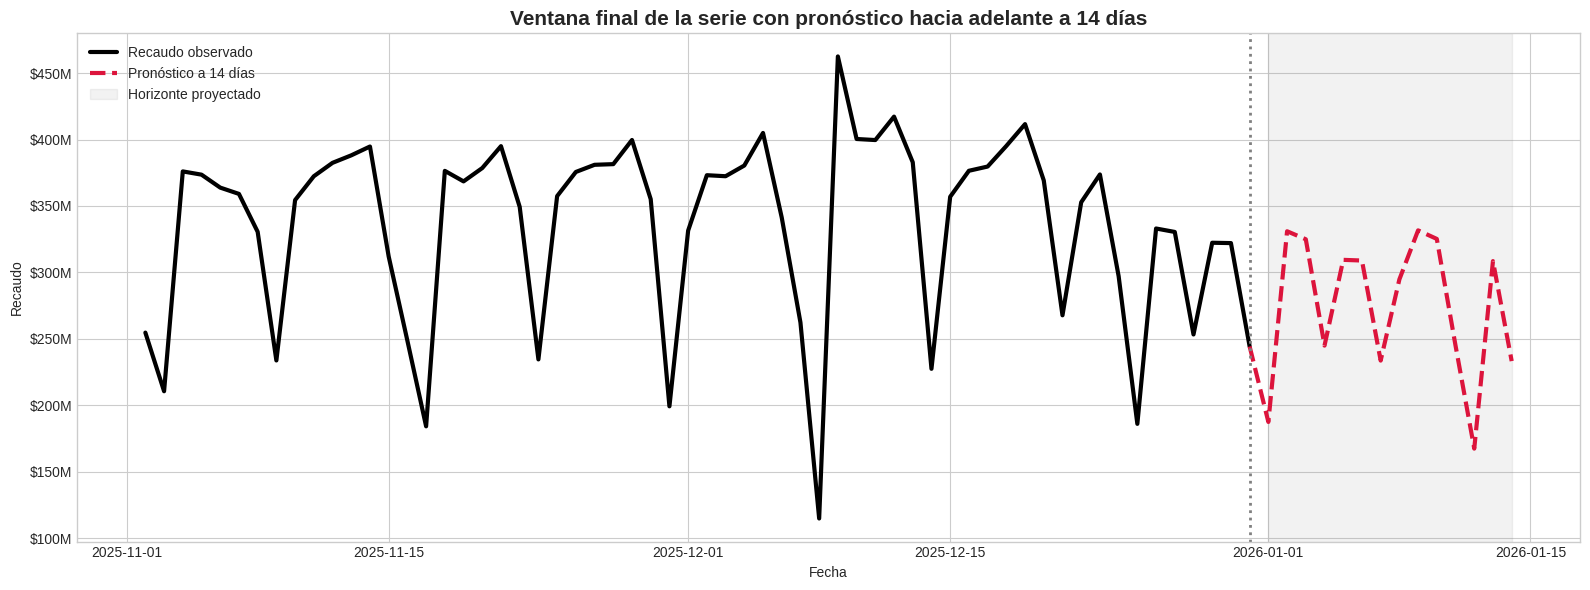

In [59]:
# ============================================================
# FASE FINAL CORREGIDA
# Pronóstico verdadero hacia adelante a 14 días
# ============================================================

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from sklearn.preprocessing import StandardScaler
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tools.sm_exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=ConvergenceWarning)

# ------------------------------------------------------------
# 1. Selecciono el mejor modelo
# ------------------------------------------------------------

mejor_modelo = resumen_bt.sort_values("WAPE").iloc[0]["modelo"]
print("Mejor modelo seleccionado:", mejor_modelo)

# ------------------------------------------------------------
# 2. Preparo la base final
# ------------------------------------------------------------

final_df = df_modelo.copy()
final_df["fecha"] = pd.to_datetime(final_df["fecha"])
final_df = final_df.sort_values("fecha").reset_index(drop=True)

target = "recaudo"

exog_cols = [
    "ACPM", "GMC", "GME",
    "lluvia_mm", "horas_lluvia", "temp_media_c",
    "festivo_colombia", "puente_festivo",
    "semana_santa", "vacaciones_mitad_ano",
    "receso_octubre", "temporada_fin_de_ano"
]
exog_cols = [c for c in exog_cols if c in final_df.columns]

final_df = final_df.dropna(subset=[target] + exog_cols).copy()
final_df["y_log"] = np.log1p(final_df[target])

print("Última fecha observada:", final_df["fecha"].max().date())

# ------------------------------------------------------------
# 3. Creo 14 fechas futuras reales
# ------------------------------------------------------------

horizonte = 14
ultima_fecha = final_df["fecha"].max()

futuro = pd.DataFrame({
    "fecha": pd.date_range(
        start=ultima_fecha + pd.Timedelta(days=1),
        periods=horizonte,
        freq="D"
    )
})

print("Pronóstico futuro:", futuro["fecha"].min().date(), "->", futuro["fecha"].max().date())

# ------------------------------------------------------------
# 4. Construyo exógenas futuras
# ------------------------------------------------------------

# 4.1 Combustibles:
# Los dejo constantes con el último valor observado,
# porque en la práctica vienen de una referencia mensual.
for col in ["ACPM", "GMC", "GME"]:
    if col in exog_cols:
        futuro[col] = final_df[col].iloc[-1]

# 4.2 Clima:
# Construyo un escenario simple por día de semana usando
# el promedio reciente de las últimas 8 semanas.
ref_clima = final_df.tail(56).copy()
ref_clima["dow"] = ref_clima["fecha"].dt.dayofweek
futuro["dow"] = futuro["fecha"].dt.dayofweek

for col in ["lluvia_mm", "horas_lluvia", "temp_media_c"]:
    if col in exog_cols:
        tabla_dow = ref_clima.groupby("dow")[col].mean()
        valor_global = ref_clima[col].mean()
        futuro[col] = futuro["dow"].map(tabla_dow).fillna(valor_global)

# 4.3 Variables calendario futuras
festivos_2026 = pd.to_datetime([
    "2026-01-01",  # Año Nuevo
    "2026-01-12",  # Reyes Magos trasladado
    "2026-03-23",  # San José trasladado
    "2026-04-02",  # Jueves Santo
    "2026-04-03",  # Viernes Santo
    "2026-05-01",  # Día del Trabajo
    "2026-05-18",  # Ascensión
    "2026-06-08",  # Corpus Christi
    "2026-06-15",  # Sagrado Corazón
    "2026-06-29",  # San Pedro y San Pablo trasladado
    "2026-07-20",  # Independencia
    "2026-08-07",  # Batalla de Boyacá
    "2026-08-17",  # Asunción
    "2026-10-12",  # Día de la Raza
    "2026-11-02",  # Todos los Santos
    "2026-11-16",  # Independencia de Cartagena
    "2026-12-08",  # Inmaculada Concepción
    "2026-12-25"   # Navidad
])

futuro["festivo_colombia"] = futuro["fecha"].isin(set(festivos_2026)).astype(int)
futuro["puente_festivo"] = (
    (futuro["festivo_colombia"] == 1) &
    (futuro["fecha"].dt.dayofweek == 0)
).astype(int)

futuro["semana_santa"] = (
    (futuro["fecha"] >= pd.Timestamp("2026-03-29")) &
    (futuro["fecha"] <= pd.Timestamp("2026-04-05"))
).astype(int)

futuro["vacaciones_mitad_ano"] = (
    (futuro["fecha"] >= pd.Timestamp("2026-06-15")) &
    (futuro["fecha"] <= pd.Timestamp("2026-07-05"))
).astype(int)

futuro["receso_octubre"] = (
    (futuro["fecha"] >= pd.Timestamp("2026-10-05")) &
    (futuro["fecha"] <= pd.Timestamp("2026-10-11"))
).astype(int)

futuro["temporada_fin_de_ano"] = (
    (futuro["fecha"] >= pd.Timestamp("2026-12-15")) &
    (futuro["fecha"] <= pd.Timestamp("2026-12-31"))
).astype(int)

# Si alguna exógena quedó faltando, la lleno con 0
for col in exog_cols:
    if col not in futuro.columns:
        futuro[col] = 0

# Limpio columna auxiliar
if "dow" in futuro.columns:
    futuro = futuro.drop(columns="dow")

# Ordeno exactamente igual que en entrenamiento
futuro = futuro[["fecha"] + exog_cols].copy()
futuro[exog_cols] = futuro[exog_cols].fillna(0)

print("\nNulos en exógenas futuras:")
print(futuro[exog_cols].isna().sum())

# ------------------------------------------------------------
# 5. Ajusto con toda la muestra y pronostico 14 días adelante
# ------------------------------------------------------------

if mejor_modelo == "Naive semanal":
    ref_hist = final_df.set_index("fecha")[target].to_dict()
    ultimo_valor = final_df[target].iloc[-1]

    pred = []
    for f in futuro["fecha"]:
        pred.append(ref_hist.get(f - pd.Timedelta(days=7), ultimo_valor))

    futuro["pronostico_recaudo"] = pred

else:
    scaler = StandardScaler()

    X_train = scaler.fit_transform(final_df[exog_cols])
    X_fut = scaler.transform(futuro[exog_cols])

    modelo_final = SARIMAX(
        final_df["y_log"],
        exog=X_train,
        order=(1, 0, 1),
        seasonal_order=(1, 0, 0, 7),
        trend="n",
        simple_differencing=True,
        enforce_stationarity=False,
        enforce_invertibility=False
    )

    ajuste_final = modelo_final.fit(disp=False, maxiter=80)

    pred_log = ajuste_final.forecast(steps=horizonte, exog=X_fut)

    # Convierto a array para evitar problemas de alineación por índice
    futuro["pronostico_recaudo"] = np.maximum(np.expm1(np.asarray(pred_log)), 0)

print("\nPronóstico futuro a 14 días:")
display(futuro[["fecha", "pronostico_recaudo"]])

print("\nNulos en pronóstico:", futuro["pronostico_recaudo"].isna().sum())

# ------------------------------------------------------------
# 6. Gráfica final no interactiva: ventana al final + forecast
# ------------------------------------------------------------

def formato_millones(x, pos):
    return f"${x/1e6:,.0f}M".replace(",", ".")

ventana_hist = 60
hist_plot = final_df[["fecha", "recaudo"]].tail(ventana_hist).copy()
fut_plot = futuro[["fecha", "pronostico_recaudo"]].copy()

plt.figure(figsize=(16, 6))

plt.plot(
    hist_plot["fecha"],
    hist_plot["recaudo"],
    linewidth=3,
    color="black",
    label="Recaudo observado"
)

# Uno el último punto observado con el primer punto proyectado
x_union = pd.concat([
    pd.Series([hist_plot["fecha"].iloc[-1]]),
    fut_plot["fecha"]
], ignore_index=True)

y_union = pd.concat([
    pd.Series([hist_plot["recaudo"].iloc[-1]]),
    fut_plot["pronostico_recaudo"]
], ignore_index=True)

plt.plot(
    x_union,
    y_union,
    linewidth=3,
    linestyle="--",
    color="crimson",
    label="Pronóstico a 14 días"
)

plt.axvspan(
    fut_plot["fecha"].min(),
    fut_plot["fecha"].max(),
    alpha=0.10,
    color="gray",
    label="Horizonte proyectado"
)

plt.axvline(
    x=hist_plot["fecha"].max(),
    color="gray",
    linestyle=":",
    linewidth=2
)

plt.title("Ventana final de la serie con pronóstico hacia adelante a 14 días", fontsize=15, weight="bold")
plt.xlabel("Fecha")
plt.ylabel("Recaudo")
plt.gca().yaxis.set_major_formatter(FuncFormatter(formato_millones))
plt.legend()
plt.tight_layout()
plt.show()

# **Conclusiones**

El proyecto partió de un modelo de pronóstico previamente desarrollado en Python sobre Google Colab, acompañado por una base histórica diaria de recaudo y movimientos de peajes,. A partir de esa información, se realizó una revisión integral del material recibido con el fin de reestructurar el proceso de modelación y orientar la construcción de un esquema de pronóstico más consistente.

En la primera etapa se depuró la base diaria, se verificó su continuidad temporal y se resolvieron tres fechas faltantes mediante una imputación estacional simple basada en los valores observados siete días antes y siete días después. Esta decisión permitió conservar la lógica semanal de la serie y dejar una base continua, ordenada y apta para las siguientes etapas. De forma paralela, se revisó la coherencia general de las variables principales y se dejó una versión limpia del conjunto de datos para el trabajo posterior.

Posteriormente se incorporaron variables explicativas externas que podían aportar capacidad predictiva adicional. En primer lugar, se construyó una tabla diaria de precios promedio de combustibles para Medellín durante 2025, incluyendo ACPM, GMC y GME, a partir de información mensual extraída de un archivo Excel con varias hojas y estructuras no totalmente uniformes. Esa información se transformó a frecuencia diaria y se integró con la base principal. En segundo lugar, se añadieron variables de calendario seleccionadas de forma parsimoniosa, concentrándose únicamente en señales con mayor plausibilidad explicativa, como festivos nacionales, puentes festivos, Semana Santa, vacaciones de mitad de año, receso de octubre y temporada de fin de año. Finalmente, se incorporaron variables meteorológicas diarias descargadas vía API para Medellín, priorizando medidas escalares como precipitación acumulada del día, horas de lluvia y temperatura media.

Con la base consolidada se ejecutó una fase de backtesting orientada a comparar el desempeño fuera de muestra. En lugar de privilegiar el ajuste histórico, se aplicó una validación rolling-origin, que permitió observar el comportamiento del modelo a medida que avanzaba el tiempo y se generaban pronósticos sucesivos sobre horizontes operativos. Para simplificar el proceso y evitar problemas de convergencia, la comparación final se concentró en una referencia naive semanal y en un SARIMAX, alimentado con las variables exógenas construidas en el proyecto. Esta estrategia redujo complejidad, estabilizó la estimación y permitió obtener un procedimiento más eficiente y defendible.

Como resultado final, se seleccionó el mejor modelo con base en su error fuera de muestra, priorizando el WAPE promedio como criterio principal. Luego se reentrenó ese modelo sobre toda la muestra disponible y se generó un pronóstico de corto plazo sobre el recaudo, mostrado en una ventana final de la serie para facilitar su lectura. El trabajo permitió pasar de un esquema inicial mas bien limitado a un proceso de pronóstico mejor estructurado, con depuración de datos, inclusión de variables exógenas pertinentes, validación temporal y una salida final más clara para análisis operativo y presentación técnica.